<a href="https://colab.research.google.com/github/rdityaza/Data-Analytics/blob/main/Tugas_03_18223086_Raditya_Zaki_Athaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_A = pd.read_csv('dataset_A_machine_temperature_defects.csv')
df_B = pd.read_csv('dataset_B_machine_sensors.csv')
df_C = pd.read_csv('dataset_C_hourly_production.csv')

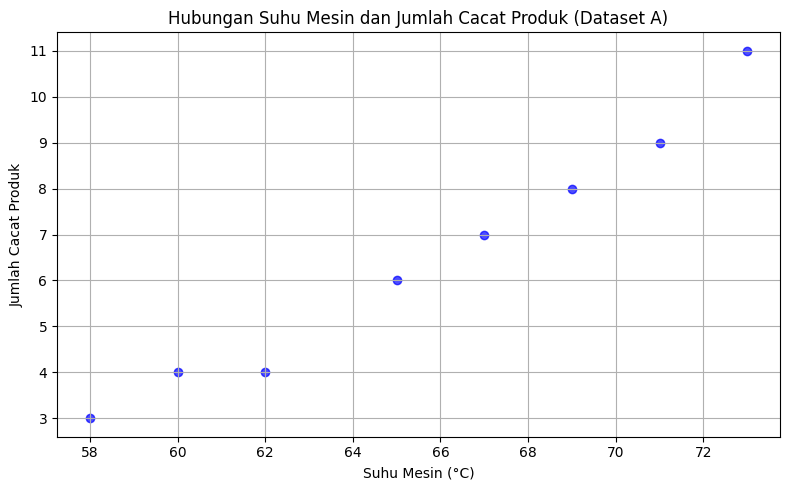

                       Shift  Temperature_C  Defective_Products
Shift               1.000000       0.998659            0.986907
Temperature_C       0.998659       1.000000            0.986615
Defective_Products  0.986907       0.986615            1.000000


In [ ]:
# Plot Dataset A: Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_A['Temperature_C'], df_A['Defective_Products'], color='blue', alpha=0.7)
plt.title('Hubungan Suhu Mesin dan Jumlah Cacat Produk (Dataset A)')
plt.xlabel('Suhu Mesin (°C)')
plt.ylabel('Jumlah Cacat Produk')
plt.grid(True)
plt.tight_layout()
plt.savefig('scatter_A.png')

plt.show()
print(df_A.corr())

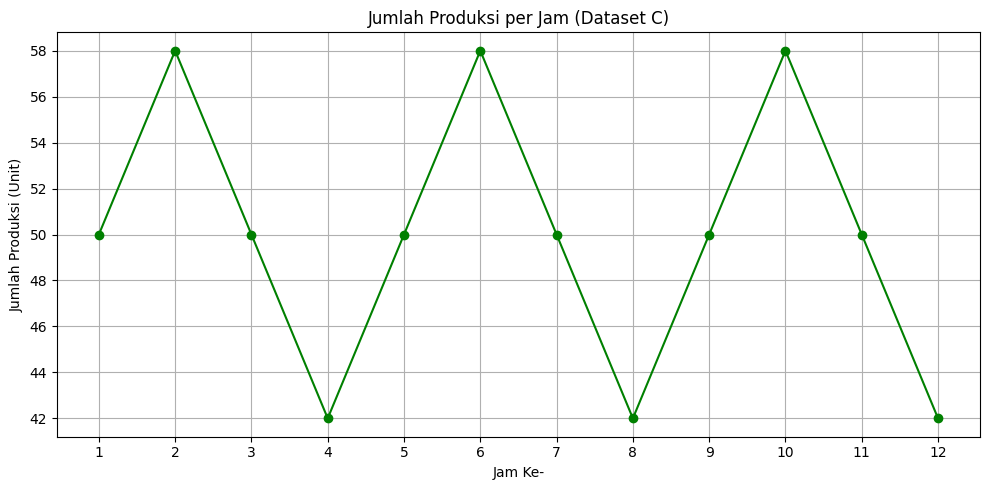

In [ ]:
# Plot Dataset C: Line Chart
plt.figure(figsize=(10, 5))
plt.plot(df_C['Hour'], df_C['Production'], marker='o', linestyle='-', color='green')
plt.title('Jumlah Produksi per Jam (Dataset C)')
plt.xlabel('Jam Ke-')
plt.ylabel('Jumlah Produksi (Unit)')
plt.grid(True)
plt.xticks(df_C['Hour'])
plt.tight_layout()
plt.savefig('line_C.png')

plt.show()

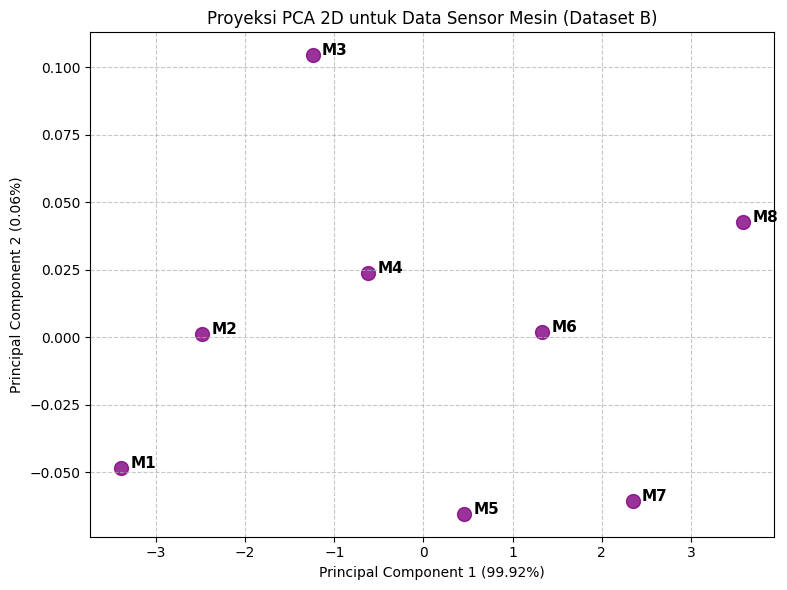

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['Vibration', 'Temperature', 'Current', 'Pressure', 'Noise']
X = df_B[features]
machines = df_B['Machine']

# Standardisasi Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Terapkan PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# Visualisasi ke Scatter Plot 2D
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], color='purple', alpha=0.8, s=100)

for i, txt in enumerate(machines):
    plt.annotate(txt, (df_pca['PC1'][i] + 0.1, df_pca['PC2'][i]), fontsize=11, fontweight='bold')

plt.title('Proyeksi PCA 2D untuk Data Sensor Mesin (Dataset B)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()